<a href="https://colab.research.google.com/github/febinonline7-oss/app-/blob/main/planet9_stageA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Planet Nine search: Stage A
### Orbit clustering → neural posterior → sky probability map

This notebook is the first stage of the combined **orbits + images** search:

| Stage | What | Output |
|---|---|---|
| **A (this notebook)** | Distant TNO orbits → AI (neural posterior estimation) → where Planet Nine could be | `p9_sky_samples.csv` |
| B | Fake-planet injection + CNN on survey images, focused on the Stage A map | detection efficiency |
| C | Focused image search, then feed detections / non-detections back into Stage A | updated constraints |

**Sections**
1. Get the data (distant TNOs from JPL's Small-Body Database)
2. Look at the clustering and measure it
3. A forward simulator: planet → population → what surveys would detect
4. Is the clustering real? (bias-aware null test)
5. Train the neural posterior (the AI part) and check it on data with a known answer
6. Run it on the real objects
7. Turn the posterior into a sky map: RA/Dec, distance, brightness, motion rate
8. Preview of Stage C: how a non-detection shrinks the map
9. Upgrade path: replacing the toy simulator with REBOUND N-body runs

> ⚠️ **Read this before trusting any number.** The simulator in Section 3 is a *phenomenological v0 model*:
> it captures the qualitative behaviour of Planet Nine (anti-aligned perihelia, shared orbital plane,
> stronger confinement for more massive/closer planets) and a *toy* survey selection function.
> It is good for building and testing the whole pipeline. For publishable results it must be replaced by
> N-body simulations (Section 9) and a real survey simulator. Every place this matters is marked **(v0)**.

Runs on a laptop or Google Colab (CPU is fine; ~5–10 min total).

In [ ]:
# If running in Colab or a fresh environment, install the extra packages
import importlib, subprocess, sys
for pkg in ["sbi", "rebound", "astropy"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, requests, json, time, warnings
import torch
from sbi.inference import NPE
from sbi.utils import BoxUniform
import astropy.units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord, get_body_barycentric, GeocentricTrueEcliptic, Galactic

warnings.filterwarnings("ignore", category=UserWarning)
rng = np.random.default_rng(42)
torch.manual_seed(42)

# ---- plot style: calm, readable, fixed colour order ----
C_BLUE, C_ORANGE, C_AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "text.color": INK, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10, "lines.linewidth": 2,
    "axes.titleweight": "bold", "axes.titlesize": 11, "legend.frameon": False,
})

# ---- configuration ----
CFG = dict(
    a_min=250.0,          # AU  — sample cut used by Batygin & Brown style analyses
    q_min=30.0,           # AU  — try 40 to drop objects strongly perturbed by Neptune
    min_arc_days=365.0,   # drop objects with very short observation arcs (poorly known orbits)
    epoch="2026-10-01",   # date for the sky map
    n_sims=20000,         # simulations used to train the neural posterior
    n_post=20000,         # posterior samples for the sky map
)
print(CFG)

{'a_min': 250.0, 'q_min': 30.0, 'min_arc_days': 365.0, 'epoch': '2026-10-01', 'n_sims': 20000, 'n_post': 20000}


## 1. Get the data

We query JPL's Small-Body Database API for objects with `a > a_min` and `q > q_min`.
If the request fails (no internet, API down), the notebook switches to **MOCK mode**: it builds a fake
"observed" sample from the simulator with a *known* Planet Nine, so you can still run and test everything.
The mode is printed clearly in every plot title.

In [ ]:
def fetch_etnos(a_min, q_min):
    url = "https://ssd-api.jpl.nasa.gov/sbdb_query.api"
    params = {
        "fields": "full_name,a,e,i,om,w,q,ad,H,data_arc,n_obs_used",
        "sb-cdata": json.dumps({"AND": [f"a|GT|{a_min}", f"q|GT|{q_min}"]}),
    }
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    js = r.json()
    df = pd.DataFrame(js["data"], columns=js["fields"])
    for c in df.columns[1:]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["full_name"] = df["full_name"].str.strip()
    return df

MODE = "REAL"
try:
    raw = fetch_etnos(CFG["a_min"], CFG["q_min"])
    obs = raw[raw["data_arc"].fillna(0) >= CFG["min_arc_days"]].reset_index(drop=True)
    obs.to_csv("etno_sample.csv", index=False)
    print(f"Fetched {len(raw)} objects; {len(obs)} kept after arc cut (saved etno_sample.csv)")
except Exception as err:
    MODE = "MOCK"
    print("⚠️  Could not reach JPL SBDB:", repr(err)[:120])
    print("⚠️  Switching to MOCK mode — the 'observed' sample will be simulated with a known planet.")

Fetched 45 objects; 32 kept after arc cut (saved etno_sample.csv)


## 2. Orbit geometry and the clustering signal

Three angles matter:

* **ϖ = Ω + ω**, the *longitude of perihelion*: the direction the orbit's closest point faces.
* **Ω**, the *longitude of the ascending node*.
* The **orbit pole**: a unit vector perpendicular to the orbital plane, built from *i* and Ω.

If Planet Nine exists, the most distant objects should have ϖ bunched roughly 180° away from the planet's
own ϖ, and poles bunched around its orbital pole.

The **mean resultant length** R measures clustering of angles: R = 0 means evenly spread, R = 1 means all identical.

In [ ]:
D2R = np.pi / 180

def wrap360(x):
    return np.mod(x, 360.0)

def pole_vector(i_deg, om_deg):
    i, om = i_deg * D2R, om_deg * D2R
    return np.stack([np.sin(i) * np.sin(om), -np.sin(i) * np.cos(om), np.cos(i)], axis=-1)

def pole_to_i_om(h):
    h = h / np.linalg.norm(h, axis=-1, keepdims=True)
    i = np.arccos(np.clip(h[..., 2], -1, 1)) / D2R
    om = wrap360(np.arctan2(h[..., 0], -h[..., 1]) / D2R)
    return i, om

def circ_mean_R(angles_deg):
    c, s = np.cos(angles_deg * D2R).mean(), np.sin(angles_deg * D2R).mean()
    return wrap360(np.arctan2(s, c) / D2R), np.hypot(c, s)

def solve_kepler(M, e, n_iter=40):
    E = np.where(e < 0.8, M, np.pi)
    for _ in range(n_iter):
        E = E - (E - e * np.sin(E) - M) / (1 - e * np.cos(E))
    return E

def helio_ecliptic_xyz(a, e, i_deg, om_deg, w_deg, M_deg):
    # heliocentric ecliptic J2000 position (AU) from orbital elements and mean anomaly
    E = solve_kepler(np.mod(M_deg * D2R, 2 * np.pi), e)
    return helio_xyz_from_E(a, e, i_deg, om_deg, w_deg, E)

def helio_xyz_from_E(a, e, i_deg, om_deg, w_deg, E):
    i, om, w = i_deg * D2R, om_deg * D2R, w_deg * D2R
    xp, yp = a * (np.cos(E) - e), a * np.sqrt(1 - e**2) * np.sin(E)
    cw, sw, co, so, ci, si = np.cos(w), np.sin(w), np.cos(om), np.sin(om), np.cos(i), np.sin(i)
    P = np.stack([cw*co - sw*so*ci, cw*so + sw*co*ci, sw*si])
    Q = np.stack([-sw*co - cw*so*ci, -sw*so + cw*co*ci, cw*si])
    return (xp * P + yp * Q).T

In [ ]:
if MODE == "REAL":
    obs["varpi"] = wrap360(obs["om"] + obs["w"])
    varpi_mean, R_varpi = circ_mean_R(obs["varpi"].values)
    om_mean, R_om = circ_mean_R(obs["om"].values)
    print(f"N = {len(obs)}")
    print(f"ϖ: mean direction {varpi_mean:.0f}°, R = {R_varpi:.2f}")
    print(f"Ω: mean direction {om_mean:.0f}°, R = {R_om:.2f}")
    display(obs.sort_values("a", ascending=False).head(15)[["full_name","a","e","i","om","w","varpi","q","data_arc"]])
else:
    print("MOCK mode: the observed sample is built in Section 3 once the simulator exists.")

N = 32
ϖ: mean direction 63°, R = 0.21
Ω: mean direction 119°, R = 0.23


,full_name,a,e,i,om,w,varpi,q,data_arc
13,(2014 FE72),2687.0,0.9866,20.60,336.74,134.04,110.78,36.051,2549
3,541132 Leleakuhonua (2015 TG387),1346.0,0.9519,11.68,301.13,118.23,59.36,64.681,7022
28,(2019 EU5),1341.0,0.9650,18.16,109.14,108.86,218.00,46.985,1837
30,(2021 RR205),949.0,0.9414,7.65,108.45,208.63,317.08,55.604,2549
29,(2021 DK18),859.3,0.9481,15.39,322.28,234.35,196.63,44.577,1472
26,(2017 OF201),823.6,0.9452,16.22,328.76,337.84,306.60,45.145,5153
12,(2013 SY99),812.9,0.9386,4.23,29.51,32.28,61.79,49.906,4433
22,(2015 KG163),640.2,0.9368,14.00,219.13,31.94,251.07,40.482,739
2,523622 (2007 TG422),555.3,0.9358,18.57,112.96,285.93,38.89,35.622,6659
0,90377 Sedna (2003 VB12),543.7,0.8599,11.93,144.51,311.10,95.61,76.185,12939


## 3. Forward simulator (v0)

**Parameters θ of Planet Nine:** mass `m9` (Earth masses), semi-major axis `a9`, eccentricity `e9`,
inclination `i9`, longitude of perihelion `ϖ9`, ascending node `Ω9`.
`m9 = 0` means **no planet**, so the "no Planet Nine" case sits inside the prior.

**For each parameter set the simulator does three things:**

1. **Intrinsic population.** Draw distant TNOs: `a` ∝ a⁻¹·⁵ (250–1500 AU), `q` uniform 30–70 AU, absolute magnitude H from a power law.
2. **Planet's influence (v0, phenomenological).** A forcing strength `F = (m9/5) · (500 AU / b9)³ · (a/500 AU)^1.5`,
   where `b9 = a9·√(1−e9²)`. Each object is *confined* with probability `1 − exp(−2F)`:
   its ϖ sits near `ϖ9 + 180°` and its pole near the planet's pole, with a scatter that shrinks as F grows.
   Unconfined objects have random ϖ and Ω.
3. **Survey selection (v0, toy).** Each object gets a random position along its orbit. It is detected with a
   probability that depends on its brightness `V ≈ H + 10·log10(r)` against a limiting magnitude that is
   **shallower near the Milky Way** (where the galactic plane crosses the ecliptic, λ ≈ 86° and 266°) and
   **far from the ecliptic**. This creates *fake* clustering on purpose, because real surveys do too.

The simulator then keeps the first N detections (N = size of the observed sample) and reduces them to a
short vector of **summary statistics** that the neural network sees.

In [ ]:
PARAM_NAMES = ["m9 [M⊕]", "a9 [AU]", "e9", "i9 [°]", "ϖ9 [°]", "Ω9 [°]"]
LOW  = np.array([0.0,  300.0, 0.05,  0.0,   0.0,   0.0])
HIGH = np.array([20.0, 1000.0, 0.60, 40.0, 360.0, 360.0])

GAL_CROSSINGS = np.array([86.0, 266.0])   # ecliptic longitudes where the Milky Way crosses (approx.)

def sample_population(n, rng):
    u1, u2, u3 = rng.random(n), rng.random(n), rng.random(n)
    lo, hi = 250.0**-0.5, 1500.0**-0.5
    a = (lo - u1 * (lo - hi)) ** -2                       # dN/da ∝ a^-1.5
    q = 30.0 + 40.0 * u2
    alpha, H0, H1 = 0.5, 3.0, 8.0                          # N(<H) ∝ 10^(alpha H)
    H = np.log10(10**(alpha*H0) + u3 * (10**(alpha*H1) - 10**(alpha*H0))) / alpha
    return a, np.clip(1 - q / a, 0, 0.995), H

def orbital_angles(theta, a, rng):
    m9, a9, e9, i9, vp9, om9 = theta
    n = len(a)
    b9 = a9 * np.sqrt(1 - e9**2)
    F = (m9 / 5.0) * (500.0 / b9) ** 3 * (a / 500.0) ** 1.5
    confined = rng.random(n) < (1 - np.exp(-2 * F))

    # unconfined: random orientation, modest inclinations to the ecliptic
    inc = np.minimum(np.abs(rng.normal(0, 15, n)), 80)
    om = rng.uniform(0, 360, n)
    varpi = rng.uniform(0, 360, n)

    if confined.any():
        k = confined.sum()
        Fk = F[confined]
        sig_vp = 20 + 40 / (1 + Fk)                           # degrees
        sig_pole = (6 + 12 / (1 + Fk)) * D2R
        varpi[confined] = wrap360(vp9 + 180 + rng.normal(0, 1, k) * sig_vp)
        h9 = pole_vector(np.array([i9]), np.array([om9]))[0]
        ref = np.array([0, 0, 1.0]) if abs(h9[2]) < 0.99 else np.array([1.0, 0, 0])
        e1 = np.cross(h9, ref); e1 /= np.linalg.norm(e1); e2 = np.cross(h9, e1)
        delta = np.abs(rng.normal(0, 1, k)) * sig_pole
        phi = rng.uniform(0, 2*np.pi, k)
        h = (np.cos(delta)[:, None] * h9 + np.sin(delta)[:, None] *
             (np.cos(phi)[:, None] * e1 + np.sin(phi)[:, None] * e2))
        inc[confined], om[confined] = pole_to_i_om(h)
    w = wrap360(varpi - om)
    return inc, om, w, confined

def detection_prob(xyz, H):
    r = np.linalg.norm(xyz, axis=1)
    lam = wrap360(np.arctan2(xyz[:, 1], xyz[:, 0]) / D2R)
    beta = np.arcsin(xyz[:, 2] / r) / D2R
    dgal = np.min(np.abs(((lam[:, None] - GAL_CROSSINGS) + 180) % 360 - 180), axis=1)
    V = H + 10 * np.log10(r)
    Vlim = 24.5 - 2.0 * np.exp(-(dgal / 20) ** 2) - 1.5 * (np.abs(beta) > 25)
    return 1 / (1 + np.exp((V - Vlim) / 0.25))

def sample_time_weighted_E(e, rng):
    # eccentric anomaly at a uniformly random *time*: density ∝ (1 - e cos E). No Kepler solve needed.
    E = rng.uniform(0, 2*np.pi, len(e))
    bad = rng.random(len(e)) * (1 + e) > (1 - e * np.cos(E))
    while bad.any():
        E[bad] = rng.uniform(0, 2*np.pi, bad.sum())
        bad[bad] = rng.random(bad.sum()) * (1 + e[bad]) > (1 - e[bad] * np.cos(E[bad]))
    return E

def simulate_detected(theta, n_det, rng, pool=20000, max_rounds=10):
    out, n_got = [], 0
    for _ in range(max_rounds):
        a, e, H = sample_population(pool, rng)
        E = sample_time_weighted_E(e, rng)
        r = a * (1 - e * np.cos(E))
        c = H + 10 * np.log10(r) < 25.5              # cheap pre-cut: fainter objects are never detected
        a, e, H, E = a[c], e[c], H[c], E[c]
        inc, om, w, _ = orbital_angles(theta, a, rng)
        xyz = helio_xyz_from_E(a, e, inc, om, w, E)
        det = rng.random(len(a)) < detection_prob(xyz, H)
        out.append(np.stack([a[det], e[det], inc[det], om[det], w[det]], axis=1))
        n_got += det.sum()
        if n_got >= n_det:
            break
    arr = np.concatenate(out)[:n_det]
    return pd.DataFrame(arr, columns=["a", "e", "i", "om", "w"])

def summary_stats(df):
    # permutation-invariant summaries; vector components avoid the 0°/360° wrap problem
    vp = wrap360(df["om"].values + df["w"].values) * D2R
    om = df["om"].values * D2R
    h = pole_vector(df["i"].values, df["om"].values)
    far = df["a"].values > np.median(df["a"].values)
    hm = h.mean(axis=0)
    return np.array([
        np.cos(vp).mean(), np.sin(vp).mean(),
        np.cos(om).mean(), np.sin(om).mean(),
        hm[0], hm[1], hm[2], 1 - np.linalg.norm(hm),
        np.cos(vp[far]).mean(), np.sin(vp[far]).mean(),
        np.median(df["i"].values) / 40.0,
    ], dtype=np.float32)

STAT_NAMES = ["cos ϖ", "sin ϖ", "cos Ω", "sin Ω", "pole x", "pole y", "pole z",
              "pole spread", "cos ϖ (far)", "sin ϖ (far)", "median i/40"]

**MOCK mode only:** create a fake observed sample from a planet we choose (values near the
Batygin et al. 2019 preferred solution), so the pipeline can be tested against a known answer.

In [ ]:
THETA_MOCK = np.array([6.0, 500.0, 0.25, 18.0, 250.0, 100.0])
if MODE == "MOCK":
    obs = simulate_detected(THETA_MOCK, 60, np.random.default_rng(7))
    obs["varpi"] = wrap360(obs["om"] + obs["w"])
    obs["full_name"] = [f"mock_{k:03d}" for k in range(len(obs))]
    print("MOCK sample built with θ =", dict(zip(PARAM_NAMES, THETA_MOCK)))

N_OBS = len(obs)
x_obs = summary_stats(obs)
print("N_OBS =", N_OBS)
print(pd.Series(x_obs, index=STAT_NAMES).round(3).to_string())

N_OBS = 32
cos ϖ          0.096
sin ϖ          0.184
cos Ω         -0.112
sin Ω          0.201
pole x         0.085
pole y         0.051
pole z         0.939
pole spread    0.056
cos ϖ (far)    0.128
sin ϖ (far)    0.160
median i/40    0.399


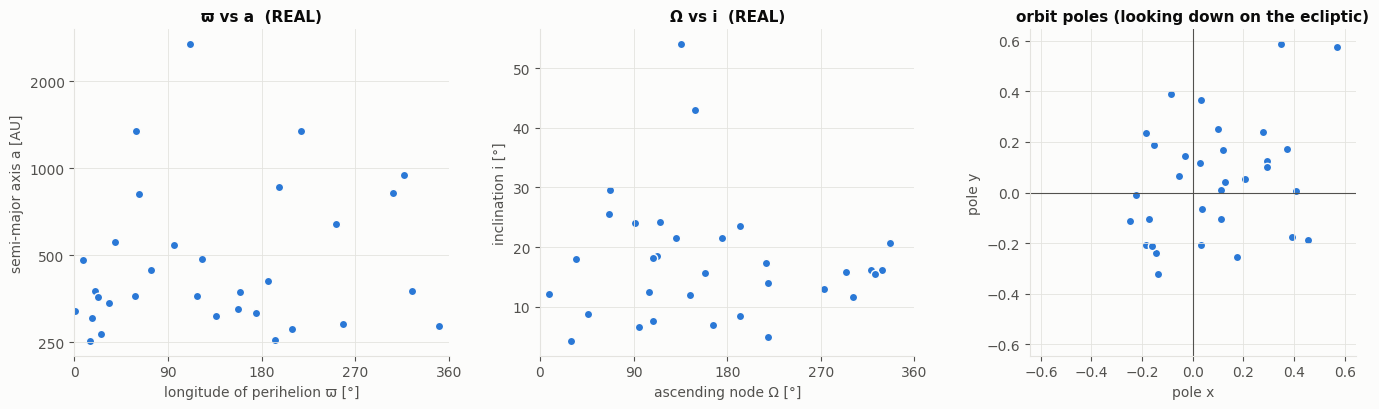

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
ax = axes[0]
ax.scatter(obs["varpi"], obs["a"], s=36, color=C_BLUE, edgecolor="#fcfcfb", linewidth=1)
ax.set_yscale("log"); ax.set_xlim(0, 360); ax.set_xticks(range(0, 361, 90))
ax.set_yticks([250, 500, 1000, 2000]); ax.set_yticklabels(["250", "500", "1000", "2000"]); ax.minorticks_off()
ax.set_xlabel("longitude of perihelion ϖ [°]"); ax.set_ylabel("semi-major axis a [AU]")
ax.set_title(f"ϖ vs a  ({MODE})")

ax = axes[1]
ax.scatter(obs["om"], obs["i"], s=36, color=C_BLUE, edgecolor="#fcfcfb", linewidth=1)
ax.set_xlim(0, 360); ax.set_xticks(range(0, 361, 90))
ax.set_xlabel("ascending node Ω [°]"); ax.set_ylabel("inclination i [°]")
ax.set_title(f"Ω vs i  ({MODE})")

ax = axes[2]
h = pole_vector(obs["i"].values, obs["om"].values)
ax.scatter(h[:, 0], h[:, 1], s=36, color=C_BLUE, edgecolor="#fcfcfb", linewidth=1)
ax.axhline(0, color=INK2, lw=0.8); ax.axvline(0, color=INK2, lw=0.8)
ax.set_aspect("equal"); lim = max(0.6, np.abs(h[:, :2]).max() * 1.1)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("pole x"); ax.set_ylabel("pole y")
ax.set_title("orbit poles (looking down on the ecliptic)")
plt.tight_layout(); plt.show()

## 4. Is the clustering real? A bias-aware null test

A plain statistical test asks: *"would random angles cluster this much?"* That ignores survey bias.
The better question is: *"would a universe **with no planet**, observed by **these surveys**, cluster this much?"*

We run the simulator many times with `m9 = 0` and count how often the fake data cluster in ϖ at least as strongly
as the observed sample. **(v0: only as good as the toy selection model.)**

Observed R_ϖ = 0.207
p-value, ignoring survey bias      : 0.2506
p-value, with (toy) survey bias    : 0.2460


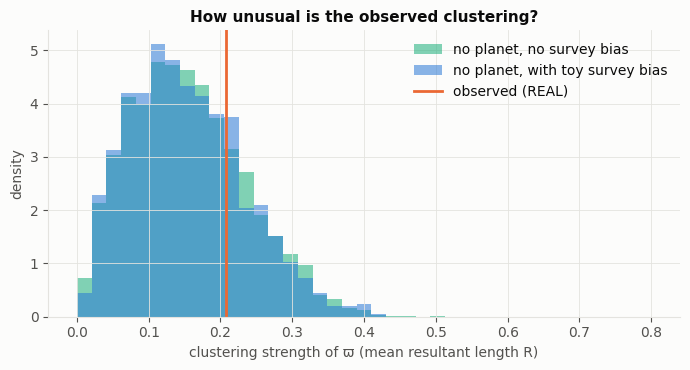

In [ ]:
def R_varpi_of(df):
    return circ_mean_R(wrap360(df["om"].values + df["w"].values))[1]

R_obs = R_varpi_of(obs)
null_rng = np.random.default_rng(123)
R_null_bias = np.array([R_varpi_of(simulate_detected(np.array([0, 500, 0.2, 0, 0, 0]), N_OBS, null_rng))
                        for _ in range(1000)])
R_null_iso = np.array([circ_mean_R(null_rng.uniform(0, 360, N_OBS))[1] for _ in range(5000)])

p_iso = (R_null_iso >= R_obs).mean()
p_bias = (R_null_bias >= R_obs).mean()
print(f"Observed R_ϖ = {R_obs:.3f}")
print(f"p-value, ignoring survey bias      : {p_iso:.4f}")
print(f"p-value, with (toy) survey bias    : {p_bias:.4f}")

fig, ax = plt.subplots(figsize=(7, 3.8))
bins = np.linspace(0, max(0.8, R_obs * 1.2), 40)
ax.hist(R_null_iso, bins=bins, density=True, color=C_AQUA, alpha=0.55, label="no planet, no survey bias")
ax.hist(R_null_bias, bins=bins, density=True, color=C_BLUE, alpha=0.55, label="no planet, with toy survey bias")
ax.axvline(R_obs, color=C_ORANGE, lw=2, label=f"observed ({MODE})")
ax.set_xlabel("clustering strength of ϖ (mean resultant length R)"); ax.set_ylabel("density")
ax.set_title("How unusual is the observed clustering?"); ax.legend()
plt.tight_layout(); plt.show()

## 5. The AI part: neural posterior estimation (NPE)

Instead of writing down a likelihood (impossible here), we:

1. draw many θ from the prior,
2. simulate a detected sample for each and compute its summary statistics x,
3. train a neural density estimator (a normalizing flow, via the `sbi` package) to learn **p(θ | x)**.

Once trained, it gives a posterior for *any* observed x in milliseconds. This is also what makes Stage C
cheap: we can re-evaluate after every new data set.

In [ ]:
t0 = time.time()
sim_rng = np.random.default_rng(2026)
theta_train = LOW + (HIGH - LOW) * sim_rng.random((CFG["n_sims"], 6))
x_train = np.stack([summary_stats(simulate_detected(th, N_OBS, sim_rng)) for th in theta_train])
print(f"{CFG['n_sims']} simulations in {time.time() - t0:.0f} s")
np.savez_compressed("training_set.npz", theta=theta_train, x=x_train)

20000 simulations in 120 s


In [ ]:
prior = BoxUniform(low=torch.tensor(LOW, dtype=torch.float32), high=torch.tensor(HIGH, dtype=torch.float32))
inference = NPE(prior=prior, show_progress_bars=False)
t0 = time.time()
density_estimator = inference.append_simulations(
    torch.tensor(theta_train, dtype=torch.float32), torch.tensor(x_train, dtype=torch.float32)
).train(training_batch_size=256)
posterior = inference.build_posterior(density_estimator)
print(f"trained in {time.time() - t0:.0f} s, epochs: {len(inference.summary['training_loss'])}")

 Neural network successfully converged after 144 epochs.trained in 138 s, epochs: 144


### 5b. Does the AI get the right answer when we know the truth?

**Recovery test:** simulate data from planets we choose and check whether the posterior finds them.
Also a **no-planet test** (`m9 = 0`): the posterior on mass should pile up near zero.

**What to expect:** the planet's *direction* (ϖ9) is recovered sharply, but **mass and distance are broad**.
That is physics, not a bug: a heavier planet farther away pushes on the TNOs about as hard as a lighter, closer one
(forcing ∝ m9 / b9³). Clustering alone cannot separate them. The image search in Stage C can, because a closer
planet is also brighter.

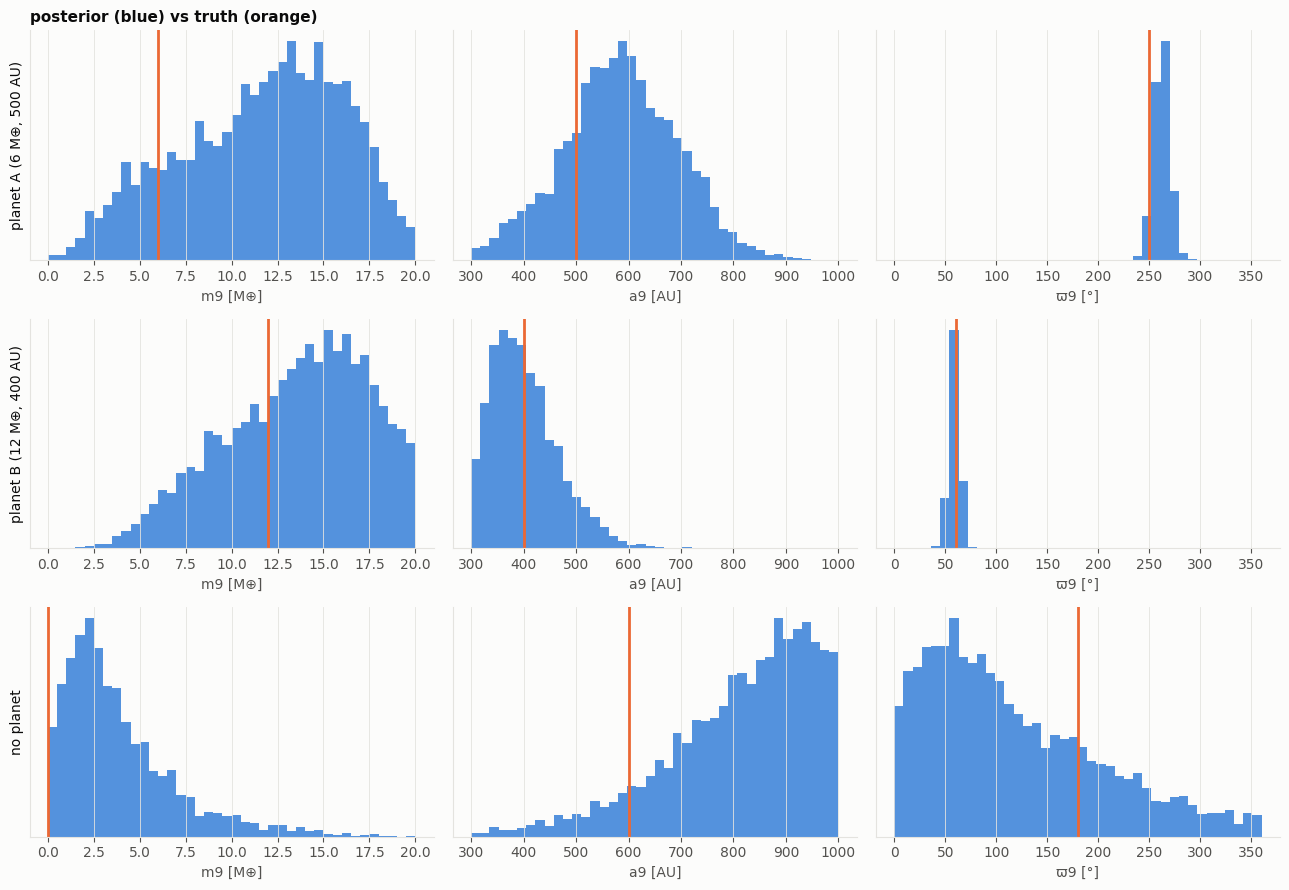

In [ ]:
def post_samples(x, n=4000):
    return posterior.sample((n,), x=torch.tensor(x, dtype=torch.float32), show_progress_bars=False).numpy()

tests = {
    "planet A (6 M⊕, 500 AU)": np.array([6.0, 500, 0.25, 18, 250, 100]),
    "planet B (12 M⊕, 400 AU)": np.array([12.0, 400, 0.3, 10, 60, 250]),
    "no planet": np.array([0.0, 600, 0.3, 20, 180, 180]),
}
test_rng = np.random.default_rng(99)
fig, axes = plt.subplots(len(tests), 3, figsize=(13, 3.0 * len(tests)))
for row, (label, th) in enumerate(tests.items()):
    s = post_samples(summary_stats(simulate_detected(th, N_OBS, test_rng)))
    for col, k in enumerate([0, 1, 4]):
        ax = axes[row, col]
        ax.hist(s[:, k], bins=40, range=(LOW[k], HIGH[k]), color=C_BLUE, alpha=0.8)
        ax.axvline(th[k], color=C_ORANGE, lw=2)
        ax.set_yticks([]); ax.set_xlabel(PARAM_NAMES[k])
        if col == 0: ax.set_ylabel(label, color=INK)
axes[0, 0].set_title("posterior (blue) vs truth (orange)", loc="left")
plt.tight_layout(); plt.show()

### 5c. Calibration check

For many simulated data sets, find where the true value falls inside its posterior (its *rank*).
If the posterior is honest, those ranks are **uniform**: the histogram should be flat.
A ∪ shape means over-confident, ∩ means under-confident. This is the check reviewers look for.

With the default settings you may see small spikes at the edges for m9 and a9 (truths near the prior boundaries
at 0/20 M⊕ and 300/1000 AU are hard to bracket). If the spikes are large: raise `n_sims`, or train several
networks with different seeds and combine their samples (an ensemble).

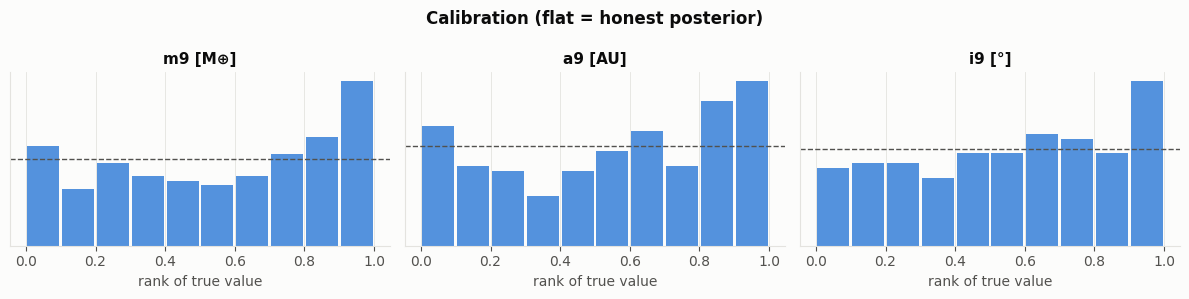

In [ ]:
n_cal, n_s = 200, 500
cal_rng = np.random.default_rng(5)
ranks = np.zeros((n_cal, 3))
for j in range(n_cal):
    th = LOW + (HIGH - LOW) * cal_rng.random(6)
    s = post_samples(summary_stats(simulate_detected(th, N_OBS, cal_rng)), n_s)
    ranks[j] = [(s[:, k] < th[k]).mean() for k in (0, 1, 3)]

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, k, name in zip(axes, range(3), [PARAM_NAMES[0], PARAM_NAMES[1], PARAM_NAMES[3]]):
    ax.hist(ranks[:, k], bins=10, range=(0, 1), color=C_BLUE, alpha=0.8, rwidth=0.92)
    ax.axhline(n_cal / 10, color=INK2, lw=1, ls="--")
    ax.set_title(name); ax.set_xlabel("rank of true value"); ax.set_yticks([])
plt.suptitle("Calibration (flat = honest posterior)", fontweight="bold"); plt.tight_layout(); plt.show()

## 6. Posterior for the observed sample

If `m9` piles up near zero, the data (under this model) do not need a planet.
If it is clearly away from zero, the clustering prefers one, and the other parameters tell us which orbit.
Angles (ϖ9, Ω9) are circular: a posterior piled at both 0° and 360° is one peak.

MODE = REAL


,16%,median,84%
m9 [M⊕],1.96,4.52,8.55
a9 [AU],652.51,828.13,935.23
e9,0.17,0.30,0.44
i9 [°],21.13,27.40,33.53
ϖ9 [°],209.58,249.66,284.16
Ω9 [°],97.72,117.40,137.94


P(m9 < 1 M⊕ | data) = 0.056


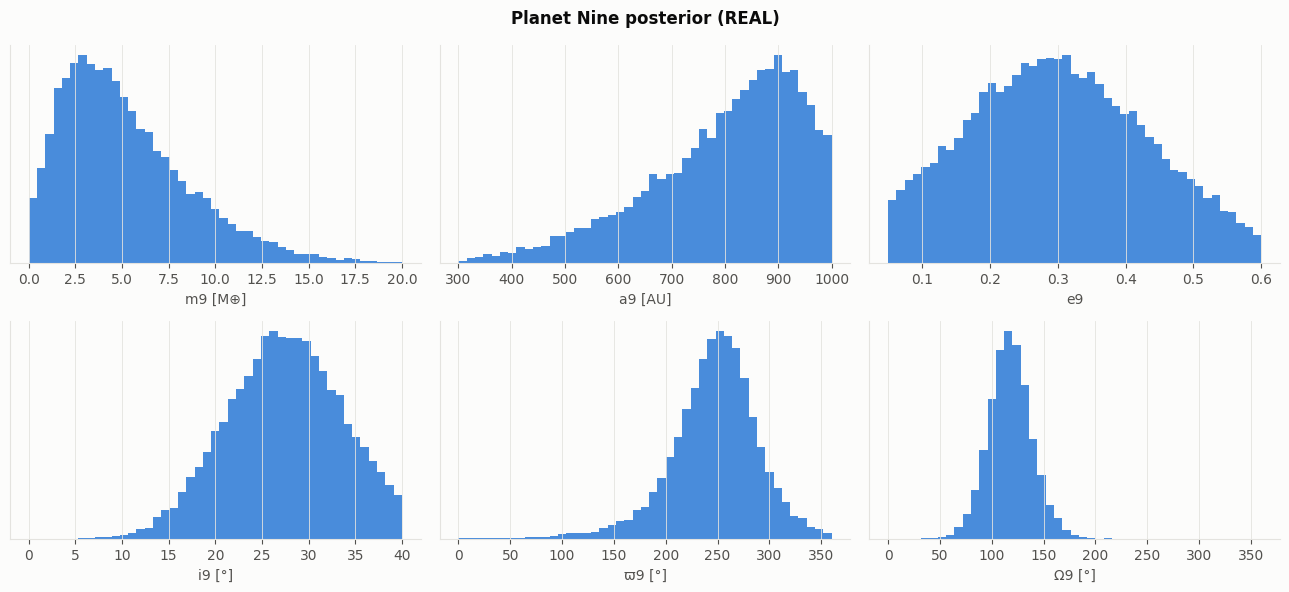

In [ ]:
samples = post_samples(x_obs, CFG["n_post"])
q = np.percentile(samples, [16, 50, 84], axis=0)
summary = pd.DataFrame({"16%": q[0], "median": q[1], "84%": q[2]}, index=PARAM_NAMES).round(2)
print(f"MODE = {MODE}"); display(summary)
print(f"P(m9 < 1 M⊕ | data) = {(samples[:, 0] < 1).mean():.3f}")

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for k, ax in enumerate(axes.flat):
    ax.hist(samples[:, k], bins=45, range=(LOW[k], HIGH[k]), color=C_BLUE, alpha=0.85)
    if MODE == "MOCK": ax.axvline(THETA_MOCK[k], color=C_ORANGE, lw=2)
    ax.set_xlabel(PARAM_NAMES[k]); ax.set_yticks([])
fig.suptitle(f"Planet Nine posterior ({MODE}{' — orange = true mock value' if MODE=='MOCK' else ''})", fontweight="bold")
plt.tight_layout(); plt.show()

## 7. From posterior to sky map (the link to the image search)

The orbit data say nothing about **where along its orbit** the planet is right now, so each posterior
sample gets a random mean anomaly M. Uniform M means the planet spends most of its time near aphelion,
so the map automatically favours the far (and faint) part of the orbit.

For every sample we compute, at `CFG['epoch']`:

* **RA / Dec** (geocentric, using Earth's actual position from astropy)
* **distance** from the Sun and from Earth
* **V magnitude**: radius from a mass–radius relation, R ≈ 0.808·M^0.589 R⊕ (Chen & Kipping 2017, Neptune-like worlds),
  a random geometric albedo 0.2–0.75, and V = H + 5·log10(r·Δ)
* **sky motion rate** and direction over one day (dominated by Earth's own motion, the parallax)

Rows with `m9 < 1 M⊕` are dropped: those are the "no planet" part of the posterior.

In [ ]:
EPS = 23.4392911 * D2R
def ecl_to_eq(xyz):
    x, y, z = xyz.T
    return np.stack([x, y*np.cos(EPS) - z*np.sin(EPS), y*np.sin(EPS) + z*np.cos(EPS)], axis=1)

def earth_helio_eq(t):
    v = get_body_barycentric("earth", t) - get_body_barycentric("sun", t)
    return v.xyz.to(u.AU).value

def sky_predictions(samples, epoch, rng, dt_days=1.0):
    s = samples[samples[:, 0] >= 1.0]
    n = len(s)
    m9, a9, e9, i9, vp9, om9 = s.T
    w9 = wrap360(vp9 - om9)
    M0 = rng.uniform(0, 360, n)
    n_deg_day = 360.0 / (a9 ** 1.5 * 365.25)                      # mean motion
    t0 = Time(epoch); t1 = t0 + dt_days * u.day
    out = {}
    for tag, t, M in [("0", t0, M0), ("1", t1, M0 + n_deg_day * dt_days)]:
        helio = ecl_to_eq(helio_ecliptic_xyz(a9, e9, i9, om9, w9, M))
        geo = helio - earth_helio_eq(t)
        dist = np.linalg.norm(geo, axis=1)
        out["ra" + tag] = wrap360(np.arctan2(geo[:, 1], geo[:, 0]) / D2R)
        out["dec" + tag] = np.arcsin(geo[:, 2] / dist) / D2R
        if tag == "0":
            out["r_sun"], out["delta"] = np.linalg.norm(helio, axis=1), dist
    R_earth = 0.808 * m9 ** 0.589
    D_km = 2 * R_earth * 6371.0
    albedo = rng.uniform(0.2, 0.75, n)
    H = 5 * np.log10(1329.0 / (D_km * np.sqrt(albedo)))
    V = H + 5 * np.log10(out["r_sun"] * out["delta"])
    c0 = SkyCoord(out["ra0"] * u.deg, out["dec0"] * u.deg)
    c1 = SkyCoord(out["ra1"] * u.deg, out["dec1"] * u.deg)
    rate = c0.separation(c1).arcsec / (24 * dt_days)               # arcsec / hour
    pa = c0.position_angle(c1).deg
    gal = c0.galactic
    return pd.DataFrame(dict(
        ra=out["ra0"], dec=out["dec0"], r_sun_AU=out["r_sun"], delta_AU=out["delta"], V_mag=V,
        rate_arcsec_hr=rate, pa_deg=pa, gal_b=gal.b.deg, m9=m9, a9=a9, e9=e9, i9=i9,
        varpi9=vp9, Omega9=om9, M9=wrap360(M0), albedo=albedo, weight=1.0,
    ))

sky = sky_predictions(samples, CFG["epoch"], np.random.default_rng(11))
sky.to_csv("p9_sky_samples.csv", index=False)
print(f"{len(sky)} sky samples saved to p9_sky_samples.csv ({MODE})")
display(sky[["r_sun_AU", "V_mag", "rate_arcsec_hr"]].describe(percentiles=[.05, .5, .95]).round(2))

18878 sky samples saved to p9_sky_samples.csv (REAL)


,r_sun_AU,V_mag,rate_arcsec_hr
count,18878.00,18878.00,18878.00
mean,856.37,23.65,0.12
std,228.33,1.23,0.07
min,204.31,18.34,0.00
5%,487.91,21.60,0.03
50%,850.36,23.67,0.12
95%,1240.43,25.65,0.24
max,1565.79,28.04,0.66


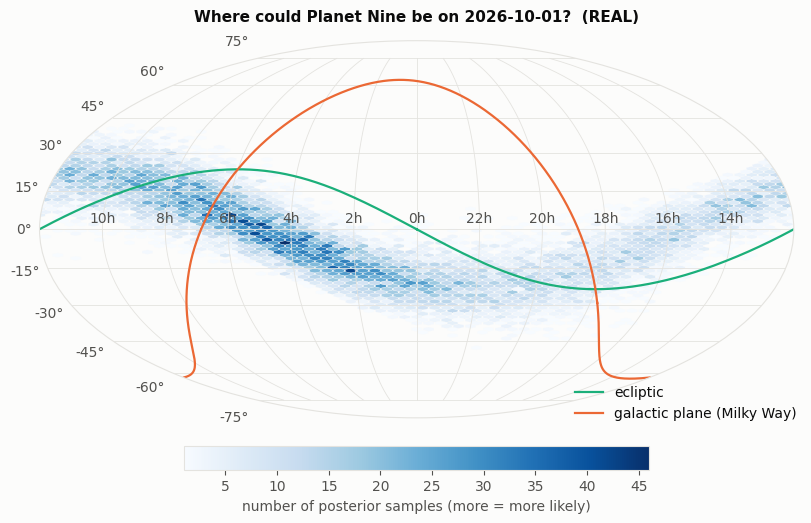

In [ ]:
def to_moll(ra_deg, dec_deg):
    x = -np.radians(((ra_deg + 180) % 360) - 180)   # RA increases to the left, as on the sky
    return x, np.radians(dec_deg)

fig = plt.figure(figsize=(12, 6.2))
ax = fig.add_subplot(111, projection="mollweide")
x, y = to_moll(sky["ra"].values, sky["dec"].values)
hb = ax.hexbin(x, y, gridsize=70, cmap="Blues", mincnt=1, linewidths=0.2, edgecolors="#fcfcfb")

lon = np.linspace(0, 360, 1441)
ecl = SkyCoord(lon * u.deg, 0 * u.deg, frame=GeocentricTrueEcliptic(equinox=Time("J2000"))).icrs
gal = SkyCoord(l=lon * u.deg, b=0 * u.deg, frame=Galactic).icrs
for c, col, lab in [(ecl, C_AQUA, "ecliptic"), (gal, C_ORANGE, "galactic plane (Milky Way)")]:
    xx, yy = to_moll(c.ra.deg, c.dec.deg)
    jumps = np.where(np.abs(np.diff(xx)) > np.pi)[0] + 1        # break the line where it wraps the map edge
    xx, yy = np.insert(xx, jumps, np.nan), np.insert(yy, jumps, np.nan)
    ax.plot(xx, yy, color=col, lw=1.6, label=lab)
# matplotlib's mollweide ticks sit at longitudes -150..150; with RA increasing leftwards they are 10h ... 14h
ax.set_xticklabels([f"{h}h" for h in [10, 8, 6, 4, 2, 0, 22, 20, 18, 16, 14]], color=INK2)
ax.grid(color=GRID, lw=0.6)
cb = fig.colorbar(hb, ax=ax, orientation="horizontal", pad=0.06, shrink=0.5)
cb.set_label("number of posterior samples (more = more likely)")
ax.legend(loc="lower right", bbox_to_anchor=(1.02, -0.04))
ax.set_title(f"Where could Planet Nine be on {CFG['epoch']}?  ({MODE})", pad=14)
plt.show()

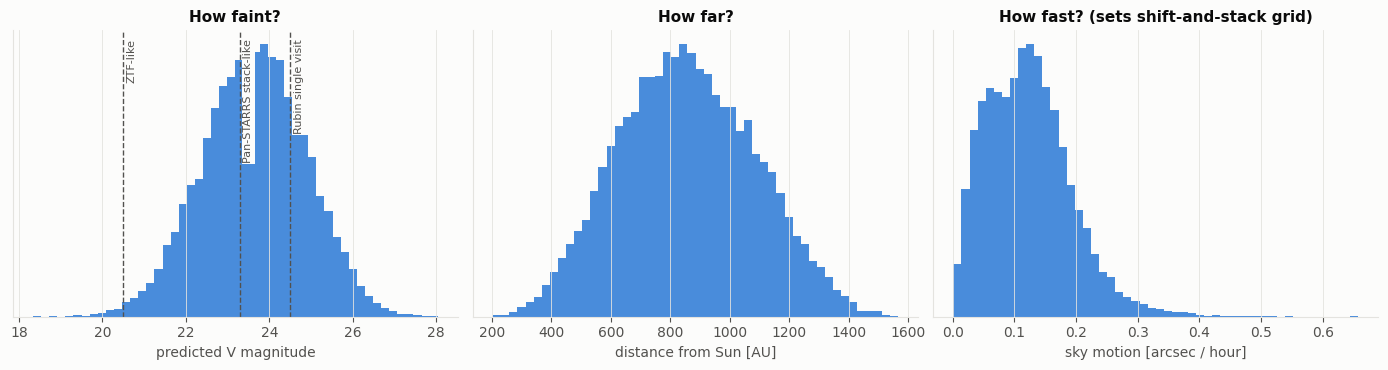

Rough limiting magnitudes shown are indicative only; use each survey's published depth in Stage B.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
axes[0].hist(sky["V_mag"], bins=50, color=C_BLUE, alpha=0.85)
ytop = axes[0].get_ylim()[1]
for lim, lab in [(20.5, "ZTF-like"), (23.3, "Pan-STARRS stack-like"), (24.5, "Rubin single visit")]:
    axes[0].axvline(lim, color=INK2, lw=1, ls="--")
    axes[0].text(lim + 0.08, ytop * 0.97, lab, fontsize=8, color=INK2, rotation=90, va="top", ha="left",
                 bbox=dict(facecolor="#fcfcfb", edgecolor="none", pad=1))
axes[0].set_xlabel("predicted V magnitude"); axes[0].set_yticks([]); axes[0].set_title("How faint?")
axes[1].hist(sky["r_sun_AU"], bins=50, color=C_BLUE, alpha=0.85)
axes[1].set_xlabel("distance from Sun [AU]"); axes[1].set_yticks([]); axes[1].set_title("How far?")
axes[2].hist(sky["rate_arcsec_hr"], bins=50, color=C_BLUE, alpha=0.85)
axes[2].set_xlabel("sky motion [arcsec / hour]"); axes[2].set_yticks([]); axes[2].set_title("How fast? (sets shift-and-stack grid)")
plt.tight_layout(); plt.show()
print("Rough limiting magnitudes shown are indicative only; use each survey's published depth in Stage B.")

## 8. Preview of Stage C: a non-detection shrinks the map

Suppose an image search covers some region to some depth and finds **nothing**. Every sample the search
*should* have caught becomes less likely. Formally, each sample's weight is multiplied by
**1 − P(detect)**, where P(detect) comes from the fake-planet injection tests of Stage B.

Below is a **made-up survey** (Dec > −20°, away from the galactic plane, 50% efficient at V = 22.5)
just to show the mechanics. In Stage C you replace `mock_footprint` and `mock_efficiency` with the real ones.

Fraction of the Planet Nine posterior ruled out by this (mock) non-detection: 11.5%


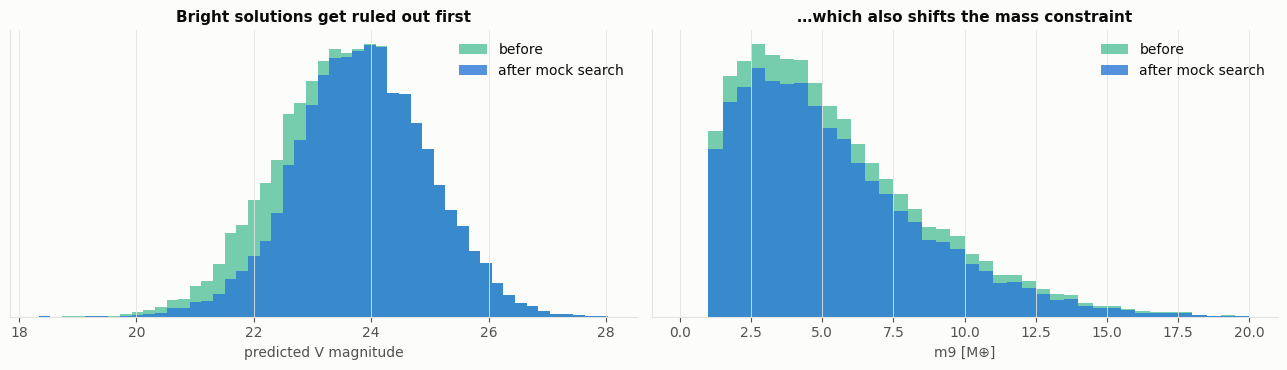

In [ ]:
def mock_footprint(df):
    return (df["dec"] > -20) & (np.abs(df["gal_b"]) > 15)

def mock_efficiency(V, V50=22.5, width=0.3, max_eff=0.9):
    return max_eff / (1 + np.exp((V - V50) / width))

def update_with_nondetection(df, footprint_fn, efficiency_fn):
    p_det = np.where(footprint_fn(df), efficiency_fn(df["V_mag"].values), 0.0)
    new = df.copy(); new["weight"] = df["weight"] * (1 - p_det)
    return new

sky_after = update_with_nondetection(sky, mock_footprint, mock_efficiency)
excluded = 1 - sky_after["weight"].sum() / sky["weight"].sum()
print(f"Fraction of the Planet Nine posterior ruled out by this (mock) non-detection: {excluded:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
bins = np.linspace(sky["V_mag"].min(), sky["V_mag"].max(), 50)
axes[0].hist(sky["V_mag"], bins=bins, color=C_AQUA, alpha=0.6, label="before")
axes[0].hist(sky_after["V_mag"], bins=bins, weights=sky_after["weight"], color=C_BLUE, alpha=0.8, label="after mock search")
axes[0].set_xlabel("predicted V magnitude"); axes[0].set_yticks([]); axes[0].legend()
axes[0].set_title("Bright solutions get ruled out first")
bins = np.linspace(0, 20, 41)
axes[1].hist(sky["m9"], bins=bins, color=C_AQUA, alpha=0.6, label="before")
axes[1].hist(sky_after["m9"], bins=bins, weights=sky_after["weight"], color=C_BLUE, alpha=0.8, label="after mock search")
axes[1].set_xlabel("m9 [M⊕]"); axes[1].set_yticks([]); axes[1].legend()
axes[1].set_title("…which also shifts the mass constraint")
plt.tight_layout(); plt.show()

## 9. Upgrade path: real N-body physics with REBOUND

The v0 simulator is the weakest link. The physically correct version:

1. Sun + Jupiter, Saturn, Uranus, Neptune + a Planet Nine with parameters θ.
2. A few hundred massless test particles in the distant Kuiper belt.
3. Integrate for ~4 Gyr, then keep particles with a > 250 AU and q > 30 AU and apply the survey selection.

Below is a **short timing run** so you know what this costs on your machine. Standard speed-ups:
replace the four giants with an equivalent solar J2 term (REBOUNDx `gravitational_harmonics`), use the
MERCURIUS integrator for close encounters with Neptune, run many θ in parallel, and train an emulator
on a few hundred N-body runs so the NPE can still use thousands of simulations.

In [ ]:
import rebound

def build_nbody(theta, n_test=50, seed=0):
    m9, a9, e9, i9, vp9, om9 = theta
    sim = rebound.Simulation(); sim.units = ("yr", "AU", "Msun")
    sim.add(m=1.0)
    for m, a, e, inc in [(9.5458e-4, 5.203, 0.048, 1.30), (2.8577e-4, 9.537, 0.054, 2.49),
                         (4.3662e-5, 19.19, 0.047, 0.77), (5.1514e-5, 30.07, 0.009, 1.77)]:
        sim.add(m=m, a=a, e=e, inc=inc * D2R, primary=sim.particles[0])
    sim.add(m=m9 * 3.003e-6, a=a9, e=e9, inc=i9 * D2R, Omega=om9 * D2R,
            omega=wrap360(vp9 - om9) * D2R, M=0.0, primary=sim.particles[0])
    sim.N_active = sim.N
    r = np.random.default_rng(seed)
    for _ in range(n_test):
        a = r.uniform(150, 550); q = r.uniform(30, 50)
        sim.add(a=a, e=1 - q / a, inc=r.uniform(0, 20) * D2R, Omega=r.uniform(0, 2*np.pi),
                omega=r.uniform(0, 2*np.pi), M=r.uniform(0, 2*np.pi), primary=sim.particles[0])
    sim.move_to_com(); sim.integrator = "whfast"; sim.dt = 0.5
    return sim

sim = build_nbody([5.0, 500, 0.25, 20, 250, 100])
t0 = time.time(); sim.integrate(1e5); cost = time.time() - t0
print(f"0.1 Myr with {sim.N - sim.N_active} test particles took {cost:.1f} s")
print(f"→ a full 4 Gyr run would take ≈ {cost * 4e4 / 3600:.0f} hours on this machine (single core, explicit giants)")

0.1 Myr with 50 test particles took 2.6 s
→ a full 4 Gyr run would take ≈ 29 hours on this machine (single core, explicit giants)


## What next

1. **Real data**: check which objects make the cut; try `q_min = 40` and see how the posterior changes.
2. **Selection function**: replace the toy `detection_prob` with a real survey simulator
   (the OSSOS survey simulator is the standard starting point).
3. **Physics**: replace `orbital_angles` with N-body results (Section 9).
4. **Stage B**: take the densest part of the sky map and the motion-rate range from `p9_sky_samples.csv`,
   pick a matching public image set, and start fake-planet injection + CNN training.

**Files written:** `etno_sample.csv` (real mode), `training_set.npz`, `p9_sky_samples.csv`.